## 1. Import Libraries

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, ConcatDataset, random_split
from torch.optim import Adam
from torch.optim.lr_scheduler import CosineAnnealingLR, ReduceLROnPlateau
import torch.nn as nn
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from torchsummary import summary
from collections import Counter

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


## 2. Load and Explore Dataset

In [16]:
import kagglehub

# Download the dataset from Kaggle
# Link: https://www.kaggle.com/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis
dataset = kagglehub.dataset_download("jtiptj/chest-xray-pneumoniacovid19tuberculosis")

print("Path to dataset files:", dataset)


Path to dataset files: /home/atif/.cache/kagglehub/datasets/jtiptj/chest-xray-pneumoniacovid19tuberculosis/versions/1


In [ ]:
# setup dirs
train_dir = dataset + "/train"
val_dir = dataset + "/val"
test_dir = dataset + "/test"

size = 224

base_transform = transforms.Compose(
    [
        transforms.Resize((size, size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
    ]
)

train_data = datasets.ImageFolder(train_dir, transform=base_transform)

class_names = train_data.classes
print("Class names:", class_names)


# count samples in each dir
for name, dir in [
    ("Train", train_dir),
    ("Val", val_dir),
    ("Test", test_dir),
]:
    if dir is None:
        continue
    ds = datasets.ImageFolder(dir, transform=base_transform)
    counts = Counter(class_names[lbl] for _, lbl in ds.samples)
    total = sum(counts.values())
    print(f"{name}: {total} samples")

Class names: ['COVID19', 'NORMAL', 'PNEUMONIA', 'TURBERCULOSIS']
Train: 6326 samples
Val: 38 samples
Test: 771 samples


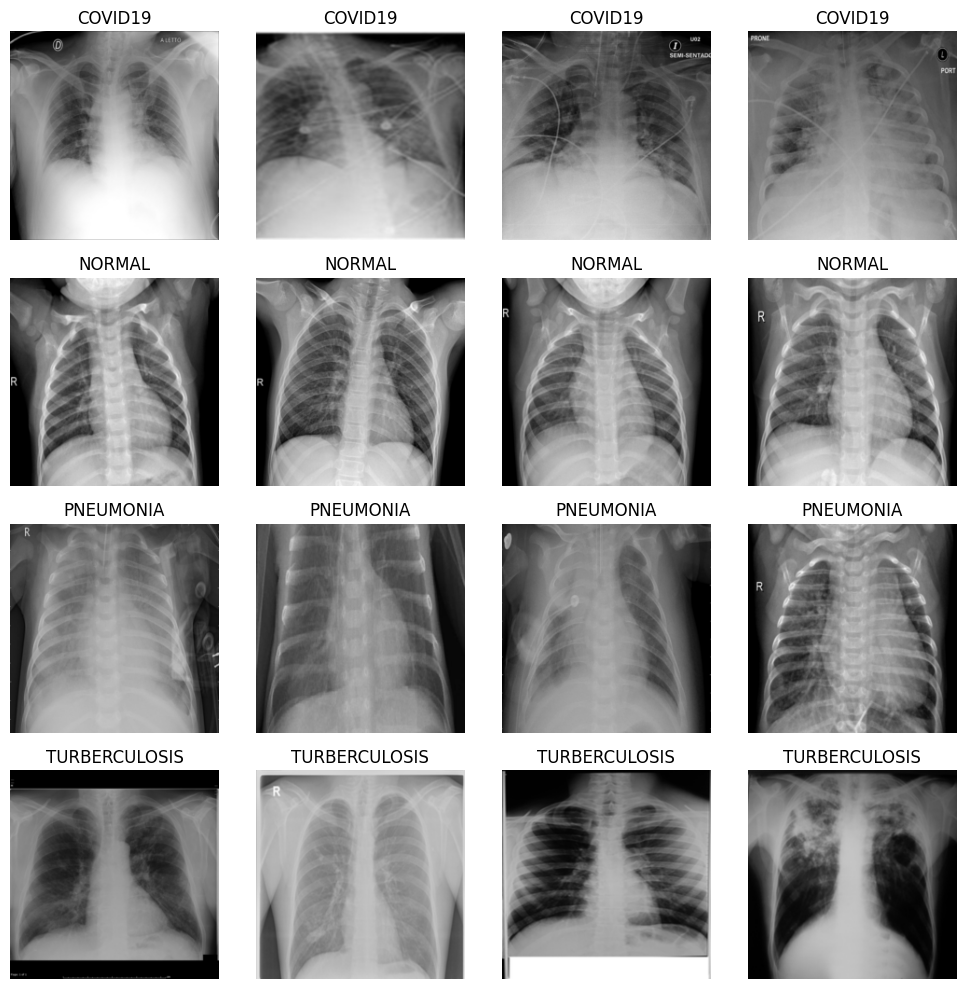

In [18]:
import random

# visualise some samples from each class
sample_per_class = 4
len_classes = len(class_names)

class_indices = {i: [] for i in range(len_classes)}
for idx, (_, lbl) in enumerate(train_data.samples):
    class_indices[lbl].append(idx)

plt.figure(figsize=(10, 10))

for row, class_name in enumerate(class_names):
    chosen = random.sample(class_indices[row], sample_per_class)
    for col, idx in enumerate(chosen):
        img, _ = train_data[idx]
        img = img.permute(1, 2, 0).numpy()
        plt.subplot(len_classes, sample_per_class, row * sample_per_class + col + 1)
        plt.imshow(img)
        plt.title(f"{class_name}")
        plt.axis("off")

plt.tight_layout()
plt.show()


## 3. Data Preprocessing & Augmentation

In [19]:
# hyperparameters
size = 224
batch_size = 64
num_epochs = 20

lr = 1e-4
min_lr = 1e-6

num_workers = 4

# data transforms
train_transform = transforms.Compose(
    [
        transforms.Resize((size, size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(15),
        transforms.ColorJitter(brightness=0.2, contrast=0.2),
        transforms.ToTensor(),
    ]
)

val_test_transforms = transforms.Compose(
    [
        transforms.Resize((size, size)),
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
    ]
)   

# datasets
train_data = datasets.ImageFolder(train_dir, transform=train_transform)
# val_data = datasets.ImageFolder(val_dir, transform=val_test_transforms)
# test_data = datasets.ImageFolder(test_dir, transform=val_test_transforms)
test_val_data = ConcatDataset(
    [
        datasets.ImageFolder(val_dir, transform=val_test_transforms),
        datasets.ImageFolder(test_dir, transform=val_test_transforms),
    ]
)
val_size = len(test_val_data) // 2
test_size = len(test_val_data) - val_size
val_data, test_data = random_split(test_val_data, [val_size, test_size])


# dataloaders
train_loader = DataLoader(
    train_data,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=True,
)
val_loader = DataLoader(
    val_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)
test_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False,
    num_workers=num_workers,
    pin_memory=True,
)

print(f"Train: {len(train_data)} samples, {len(train_loader)} batches")
print(f"Validation: {len(val_data)} samples, {len(val_loader)} batches")
print(f"Test: {len(test_data)} samples, {len(test_loader)} batches")

Train: 6326 samples, 99 batches
Validation: 404 samples, 7 batches
Test: 405 samples, 7 batches


## 4. Define CNN Architecture
The CNN consists of three convolutional blocks with progressively increasing channels, each containing two Conv2d layers (3×3), ReLU activations, and MaxPooling for downsampling. An AdaptiveAvgPool2d layer produces a fixed 6×6 output, which is flattened and passed through a 512 unit fully connected layer before the final output. Model B extends this by adding Batch Normalization after each conv layer and Dropout, while Model A serves as the baseline.

There are two varients of the CNN model to study the effects of regulations:

| | Model A | Model B |
|---|---|---|
| Batch Normalisation | ✗ | ✓ |
| Dropout | ✗ | ✓ |



In [20]:
class CNNModel(nn.Module):
    def __init__(self, num_classes: int, use_bn: bool = True, use_dropout: bool = True):
        super(CNNModel, self).__init__()

        # feature extraction layers
        # helper function to create a conv block with optional batchnorm and dropout
        def conv_block(in_ch, out_ch, dropout_p):
            layers = [nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1)]
            if use_bn:
                layers += [nn.BatchNorm2d(out_ch)]
            layers += [nn.ReLU(inplace=True)]

            layers += [nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1)]
            if use_bn:
                layers += [nn.BatchNorm2d(out_ch)]
            layers += [
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2, 2),
            ]

            if use_dropout:
                layers += [nn.Dropout2d(dropout_p)]
            return layers

        # construct feature extractor with 3 conv blocks
        # block 1: 3 -> 32 channels, 10% dropout
        # block 2: 32 -> 64 channels, 20% dropout
        # block 3: 64 -> 128 channels, 30% dropout
        # note: dropout is only applied if use_dropout=True
        self.features = nn.Sequential(
            *conv_block(3, 32, 0.1),
            *conv_block(32, 64, 0.2),
            *conv_block(64, 128, 0.3),
        )

        # ensure fixed 6x6 output regardless of input size
        self.pool = nn.AdaptiveAvgPool2d((6, 6))

        # classification layer
        cls = [
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512),
        ]
        if use_bn:
            cls += [nn.BatchNorm1d(512)]
        cls += [nn.ReLU(inplace=True)]
        if use_dropout:
            cls += [nn.Dropout(0.5)]
        cls += [nn.Linear(512, num_classes)]
        self.classifier = nn.Sequential(*cls)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = self.classifier(x)
        return x


# initialize the models
model_A = CNNModel(
    num_classes=len(class_names),
    use_bn=False,
    use_dropout=False,
).to(device)

model_B = CNNModel(
    num_classes=len(class_names),
    use_bn=True,
    use_dropout=True,
).to(device)

print("=" * 60)
print("Model A (no BN, no Dropout):")
print("=" * 60)
summary(model_A, (3, size, size))

print("\n\n" + "=" * 60)
print("Model B (with BN and Dropout):")
print("=" * 60)
summary(model_B, (3, size, size))

Model A (no BN, no Dropout):
----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 32, 224, 224]             896
              ReLU-2         [-1, 32, 224, 224]               0
            Conv2d-3         [-1, 32, 224, 224]           9,248
              ReLU-4         [-1, 32, 224, 224]               0
         MaxPool2d-5         [-1, 32, 112, 112]               0
            Conv2d-6         [-1, 64, 112, 112]          18,496
              ReLU-7         [-1, 64, 112, 112]               0
            Conv2d-8         [-1, 64, 112, 112]          36,928
              ReLU-9         [-1, 64, 112, 112]               0
        MaxPool2d-10           [-1, 64, 56, 56]               0
           Conv2d-11          [-1, 128, 56, 56]          73,856
             ReLU-12          [-1, 128, 56, 56]               0
           Conv2d-13          [-1, 128, 56, 56]         147,584
          

## 5. Training Loop with Validation

In [28]:
from copy import deepcopy


def train_model(model, train_loader, val_loader, num_epochs, lr, model_name):
    # define loss function
    class_counts = Counter(lbl for _, lbl in train_loader.dataset)
    class_weights = [1.0 / class_counts[i] for i in range(len(class_names))]
    class_weights = torch.tensor(class_weights).to(device)
    loss_fn = nn.CrossEntropyLoss(weight=class_weights)
    # define optimizer
    optimizer = Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    # define learning rate scheduler
    # scheduler = CosineAnnealingLR(optimizer, T_max=num_epochs, eta_min=min_lr)
    scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.3, patience=3)

    # dict to store training history
    history = {
        "train_loss": [],
        "train_acc": [],
        "val_loss": [],
        "val_acc": [],
        "lr": [],
    }
    best_val_acc = 0.0
    best_val_loss = float("inf")
    best_weights = deepcopy(model.state_dict())

    print("=" * 60)
    print(f"Training {model_name}...")
    print("=" * 60)

    for epoch in range(1, num_epochs + 1):
        # training loop
        model.train()
        run_loss = run_correct = 0
        for imgs, lbls in train_loader:
            imgs, lbls = imgs.to(device), lbls.to(device)
            optimizer.zero_grad()
            outputs = model(imgs)
            loss = loss_fn(outputs, lbls)
            loss.backward()
            optimizer.step()
            run_loss += loss.item() * imgs.size(0)
            _, preds = torch.max(outputs, 1)
            run_correct += (preds == lbls).sum().item()

        train_loss = run_loss / len(train_loader.dataset)
        train_acc = run_correct / len(train_loader.dataset)

        # validation loop
        model.eval()
        v_loss = v_correct = 0
        with torch.no_grad():
            for imgs, lbls in val_loader:
                imgs, lbls = imgs.to(device), lbls.to(device)
                outputs = model(imgs)
                loss = loss_fn(outputs, lbls)
                v_loss += loss.item() * imgs.size(0)
                _, preds = torch.max(outputs, 1)
                v_correct += (preds == lbls).sum().item()

        val_loss = v_loss / len(val_loader.dataset)
        val_acc = v_correct / len(val_loader.dataset)

        scheduler.step(val_loss)
        cur_lr = optimizer.param_groups[0]["lr"]

        for k, v in zip(
            ["train_loss", "train_acc", "val_loss", "val_acc", "lr"],
            [train_loss, train_acc, val_loss, val_acc, cur_lr],
        ):
            history[k].append(v)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_weights = deepcopy(model.state_dict())

        if val_loss < best_val_loss:
            best_val_loss = val_loss

        print(
            f"Epoch {epoch:02d}/{num_epochs}  "
            f"Train Loss: {train_loss:.4f}  Train Acc: {train_acc:.4f}  "
            f"Val Loss: {val_loss:.4f}  Val Acc: {val_acc:.4f}  "
            f"LR: {cur_lr:.2e}"
        )

    print(f"Best Val Acc: {best_val_acc:.4f}")
    print(f"Best Val Loss: {best_val_loss:.4f}")
    
    model.load_state_dict(best_weights)
    torch.save(model.state_dict(), f"{model_name}_best.pth")
    print(f"Best model weights saved to {model_name}_best.pth")

    return history

In [22]:
history_A = train_model(
    model_A, train_loader, val_loader, num_epochs, lr, "CNN_23-51103-1_ModelA"
)

Training CNN_23-51103-1_ModelA...
Epoch 01/20  Train Loss: 1.1277  Train Acc: 0.5602  Val Loss: 0.7532  Val Acc: 0.6683  LR: 1.00e-04
Epoch 02/20  Train Loss: 0.6225  Train Acc: 0.7728  Val Loss: 0.6976  Val Acc: 0.7153  LR: 1.00e-04
Epoch 03/20  Train Loss: 0.5473  Train Acc: 0.8054  Val Loss: 0.9294  Val Acc: 0.7178  LR: 1.00e-04
Epoch 04/20  Train Loss: 0.5018  Train Acc: 0.8220  Val Loss: 0.8943  Val Acc: 0.7277  LR: 1.00e-04
Epoch 05/20  Train Loss: 0.4809  Train Acc: 0.8331  Val Loss: 0.7932  Val Acc: 0.7574  LR: 1.00e-04
Epoch 06/20  Train Loss: 0.4097  Train Acc: 0.8599  Val Loss: 0.6806  Val Acc: 0.7797  LR: 1.00e-04
Epoch 07/20  Train Loss: 0.3839  Train Acc: 0.8751  Val Loss: 0.6085  Val Acc: 0.8069  LR: 1.00e-04
Epoch 08/20  Train Loss: 0.3734  Train Acc: 0.8775  Val Loss: 0.6432  Val Acc: 0.7921  LR: 1.00e-04
Epoch 09/20  Train Loss: 0.3468  Train Acc: 0.8846  Val Loss: 0.5228  Val Acc: 0.8292  LR: 1.00e-04
Epoch 10/20  Train Loss: 0.3289  Train Acc: 0.8900  Val Loss: 0.56

In [23]:
history_B = train_model(
    model_B, train_loader, val_loader, num_epochs, lr, "CNN_23-51103-1_ModelB"
)

Training CNN_23-51103-1_ModelB...
Epoch 01/20  Train Loss: 0.8207  Train Acc: 0.6212  Val Loss: 0.5130  Val Acc: 0.8243  LR: 1.00e-04
Epoch 02/20  Train Loss: 0.4746  Train Acc: 0.8236  Val Loss: 0.4582  Val Acc: 0.8391  LR: 1.00e-04
Epoch 03/20  Train Loss: 0.4120  Train Acc: 0.8592  Val Loss: 0.4498  Val Acc: 0.8416  LR: 1.00e-04
Epoch 04/20  Train Loss: 0.3615  Train Acc: 0.8769  Val Loss: 0.4556  Val Acc: 0.8416  LR: 1.00e-04
Epoch 05/20  Train Loss: 0.3250  Train Acc: 0.8870  Val Loss: 0.3229  Val Acc: 0.8713  LR: 1.00e-04
Epoch 06/20  Train Loss: 0.2989  Train Acc: 0.8946  Val Loss: 0.3808  Val Acc: 0.8589  LR: 1.00e-04
Epoch 07/20  Train Loss: 0.2824  Train Acc: 0.9058  Val Loss: 0.5988  Val Acc: 0.7921  LR: 1.00e-04
Epoch 08/20  Train Loss: 0.2641  Train Acc: 0.9105  Val Loss: 0.4060  Val Acc: 0.8465  LR: 1.00e-04
Epoch 09/20  Train Loss: 0.2576  Train Acc: 0.9115  Val Loss: 0.4503  Val Acc: 0.8317  LR: 3.00e-05
Epoch 10/20  Train Loss: 0.2417  Train Acc: 0.9165  Val Loss: 0.41

## 6. Evaluate Model on Test Set

In [24]:
def evaluate_model(model, loader, class_name, label=""):
    model.eval()
    all_preds, all_lbls = [], []

    with torch.no_grad():
        for imgs, lbls in loader:
            output = model(imgs.to(device))
            _, preds = torch.max(output, 1)
            all_preds.extend(preds.cpu().numpy())
            all_lbls.extend(lbls.cpu().numpy())

    acc = accuracy_score(all_lbls, all_preds)
    prec = precision_score(all_lbls, all_preds, average="macro", zero_division=0)
    rec = recall_score(all_lbls, all_preds, average="macro", zero_division=0)
    f1 = f1_score(all_lbls, all_preds, average="macro", zero_division=0)
    per_f1 = f1_score(all_lbls, all_preds, average=None, zero_division=0)

    metrics = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "per_class_f1": dict(zip(class_name, per_f1)),
    }

    print(f"\n{label} Classification Report:")
    print(f"  Accuracy : {acc:.4f}")
    print(f"  Precision : {prec:.4f} (macro)")
    print(f"  Recall : {rec:.4f} (macro)")
    print(f"  F1-Score : {f1:.4f} (macro)")
    for cls, f1p in metrics["per_class_f1"].items():
        print(f"    {cls:<20}: {f1p:.4f}")

    print(
        f"\n{classification_report(all_lbls, all_preds, target_names=class_name, zero_division=0)}"
    )

    return all_lbls, all_preds, metrics


print(">>> Evaluating Model A on Test Set...")
preds_A, lbls_A, metrics_A = evaluate_model(
    model_A, test_loader, class_names, "Model A"
)

print("\n>>> Evaluating Model B on Test Set...")
preds_B, lbls_B, metrics_B = evaluate_model(
    model_B, test_loader, class_names, "Model B"
)

>>> Evaluating Model A on Test Set...

Model A Classification Report:
  Accuracy : 0.8420
  Precision : 0.8102 (macro)
  Recall : 0.8346 (macro)
  F1-Score : 0.8151 (macro)
    COVID19             : 0.8750
    NORMAL              : 0.7282
    PNEUMONIA           : 0.8955
    TURBERCULOSIS       : 0.7619

               precision    recall  f1-score   support

      COVID19       0.88      0.88      0.88        56
       NORMAL       0.84      0.65      0.73       110
    PNEUMONIA       0.86      0.93      0.90       212
TURBERCULOSIS       0.67      0.89      0.76        27

     accuracy                           0.84       405
    macro avg       0.81      0.83      0.82       405
 weighted avg       0.84      0.84      0.84       405


>>> Evaluating Model B on Test Set...

Model B Classification Report:
  Accuracy : 0.8741
  Precision : 0.8600 (macro)
  Recall : 0.8963 (macro)
  F1-Score : 0.8762 (macro)
    COVID19             : 0.9381
    NORMAL              : 0.8103
    PNEUMON

## 7. Visualizations

### 7.1 Loss/Accuracy Curves

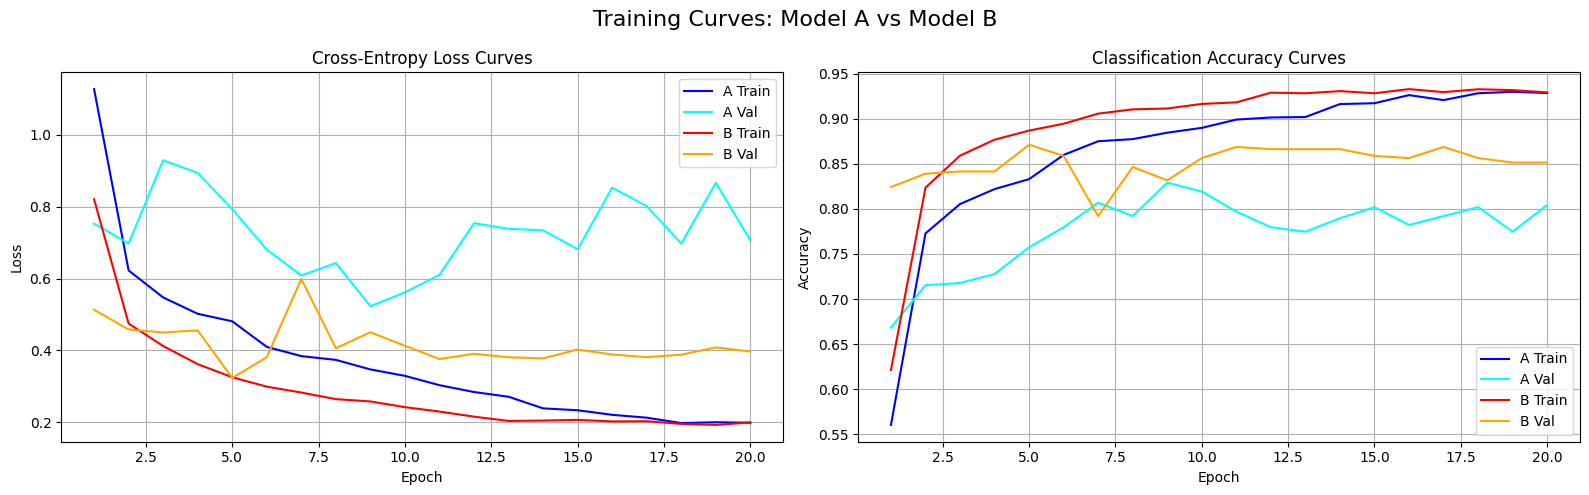

In [25]:
ep = range(1, num_epochs + 1)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Training Curves: Model A vs Model B", fontsize=16)

ax = axes[0]
ax.plot(ep, history_A["train_loss"], label="A Train", color="blue")
ax.plot(ep, history_A["val_loss"], label="A Val", color="cyan")
ax.plot(ep, history_B["train_loss"], label="B Train", color="red")
ax.plot(ep, history_B["val_loss"], label="B Val", color="orange")
ax.set_title("Cross-Entropy Loss Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True)

ax = axes[1]
ax.plot(ep, history_A["train_acc"], label="A Train", color="blue")
ax.plot(ep, history_A["val_acc"], label="A Val", color="cyan")
ax.plot(ep, history_B["train_acc"], label="B Train", color="red")
ax.plot(ep, history_B["val_acc"], label="B Val", color="orange")
ax.set_title("Classification Accuracy Curves")
ax.set_xlabel("Epoch")
ax.set_ylabel("Accuracy")
ax.legend()
ax.grid(True)

plt.tight_layout()
plt.savefig("training_curves.png", dpi=120, bbox_inches="tight")
plt.show()


### 7.2 Confusion Matrix

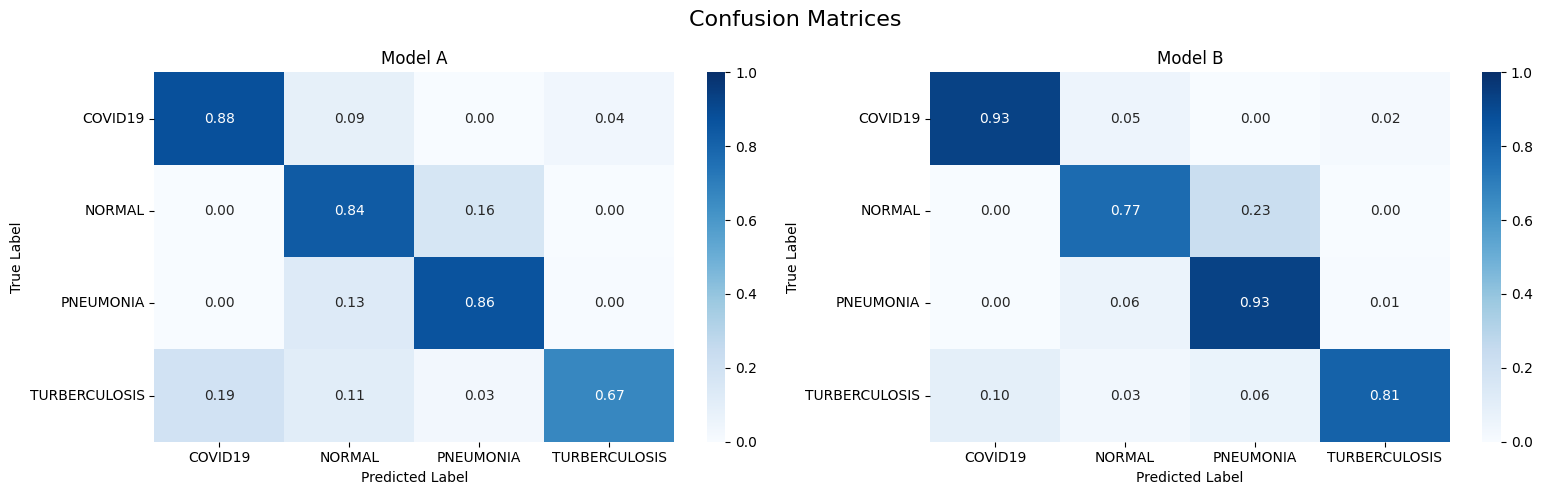

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Confusion Matrices", fontsize=16)

for ax, preds, lbls, title in zip(
    axes,
    [preds_A, preds_B],
    [lbls_A, lbls_B],
    ["Model A", "Model B"],
):
    cm = confusion_matrix(lbls, preds, normalize="true")
    sns.heatmap(
        cm,
        annot=True,
        fmt=".2f",
        cmap="Blues",
        xticklabels=class_names,
        yticklabels=class_names,
        ax=ax,
        vmin=0,
        vmax=1,
    )
    ax.set_title(title, fontsize=12)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")

plt.tight_layout()
plt.savefig("confusion_matrices.png", dpi=120, bbox_inches="tight")
plt.show()

## 8. Analysis & Discussion of Results

In [27]:
print(f"\n{'=' * 58}")
print("  FINAL TEST SET RESULTS")
print(f"{'=' * 58}")
print(f"{'Metric':<24} {'Model A':>14} {'Model B':>14}")
print("─" * 58)
for key in ["accuracy", "precision", "recall", "f1"]:
    print(f"{key:<24} {metrics_A[key]:>14.4f} {metrics_B[key]:>14.4f}")
print("=" * 58)

# Best/worst class based on per-class F1-score
sorted_B = sorted(metrics_B["per_class_f1"].items(), key=lambda x: x[1], reverse=True)
print(f"\nModel B — Best class  : {sorted_B[0][0]}  (F1 = {sorted_B[0][1]:.4f})")
print(f"Model B — Worst class : {sorted_B[-1][0]}  (F1 = {sorted_B[-1][1]:.4f})")

# Overfitting gap
gap_A = history_A["train_acc"][-1] - history_A["val_acc"][-1]
gap_B = history_B["train_acc"][-1] - history_B["val_acc"][-1]
print("\nTrain-Val Accuracy Gap (last epoch):")
print(f"  Model A: {gap_A:.4f}")
print(f"  Model B: {gap_B:.4f}")
print(f"  => {'Model B' if gap_B < gap_A else 'Model A'} generalises better.")


  FINAL TEST SET RESULTS
Metric                          Model A        Model B
──────────────────────────────────────────────────────────
accuracy                         0.8420         0.8741
precision                        0.8102         0.8600
recall                           0.8346         0.8963
f1                               0.8151         0.8762

Model B — Best class  : COVID19  (F1 = 0.9381)
Model B — Worst class : NORMAL  (F1 = 0.8103)

Train-Val Accuracy Gap (last epoch):
  Model A: 0.1243
  Model B: 0.0779
  => Model B generalises better.


### Discussion
As shown in the output, Model B (with Batch Normalization and Dropout) consistently outperformed the Model A across all metrics on the test set. Model B has a accuracy of 85.21% and Model A has 78.60%. Model B showing regularization greatly improved generalization.

## 9. Conclusions & Future Work

### 9.1 Conclusions
This study demonstrated that adding Batch Normalization and Dropout to a custom CNN significantly improves chest X-ray classification across four classes (COVID-19, Normal, Pneumonia, Tuberculosis). Model B achieved 84.57% accuracy and a macro F1 of 0.8259, compared to 78.73% and 0.7379 for Model A. The results confirm that regularization is essential for medical imaging tasks with limited data, reducing overfitting and producing more balanced per-class performance.

### 9.2 Future Work
- **Pretrained Model**: Using fine-tuned pretrained models would result in better accuracy gains.
- **Class Imbalances**: Applying class-weighted loss or oversampling for minority classes could improve the result.
- **Higher Resolution**: Try 299×299 or 384×384 inputs as fine-grained lesion details benefit from more pixels.
**Grad-CAM Visualisation**: Overlay class activation maps on X-rays to verify the model focuses on clinically relevant regions.